# 관련 단축키 설명

## 1. 셀 코드 실행

Shift + Enter: 현재 셀을 실행하고 다음 셀로 이동합니다. (가장 많이 사용)

Ctrl + Enter: 현재 셀을 실행하고 현재 셀에 머무릅니다. 결과를 확인하고 코드를 계속 수정할 때 유용합니다. (Mac: Cmd + Enter)

Alt + Enter: 현재 셀을 실행하고 바로 아래에 새로운 코드 셀을 추가합니다. (Mac: Option + Enter)

## 2. 셀 삭제

명령 모드(Esc) 상태에서:

D , D: 키보드 알파벳 D를 연속으로 두 번 타닥 누르면 셀이 삭제됩니다.

## 3. 코드 셀 만들기

명령 모드(Esc) 상태에서:

* A: 현재 셀 위(Above)에 새로운 코드 셀을 추가합니다.

* B: 현재 셀 아래(Below)에 새로운 코드 셀을 추가합니다.

* Y: 마크다운 등 다른 타입의 셀을 다시 코드(Code) 셀로 변경합니다.

## 4. 마크다운 셀 만들기

명령 모드(Esc) 상태에서:

M: 현재 셀을 마크다운(Markdown) 셀로 변경합니다.

실전 팁: 보통 마크다운 셀을 새로 만들 때는 **B**를 눌러 아래에 빈 코드 셀을 만든 직후, 바로 **M**을 눌러 마크다운 셀로 변환해서 글을 작성하는 방식을 가장 많이 사용합니다. 실수로 셀을 지웠다면 당황하지 말고 Z 키를 누르면 방금 삭제한 셀이 복구됩니다.

---

# 비전 노드 개발 관련 실험코드.

### 리얼센스 D435IF 기반 듀플로 단일 블럭 및 조립 객체 인식 상태 개발

---

## **리얼센스 카메라 인식 하는 함수**

In [3]:
import os
import time
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt

In [4]:
# import pyrealsense2 as rs


def list_realsense_devices():
    """
    현재 연결된 Intel RealSense 카메라 목록을 출력하는 함수
    """
    ctx = rs.context()
    devices = ctx.query_devices()

    device_count = len(devices)

    print(f"[INFO] 연결된 RealSense 장치 수: {device_count}")

    if device_count == 0:
        print("[WARN] 연결된 RealSense 카메라가 없습니다.")
        return []

    device_info_list = []

    for i, dev in enumerate(devices):
        print("\n" + "=" * 50)
        print(f"[DEVICE {i}]")

        info = {}

        for info_type in [
            rs.camera_info.name,
            rs.camera_info.serial_number,
            rs.camera_info.firmware_version,
            rs.camera_info.physical_port,
            rs.camera_info.product_id,
            rs.camera_info.product_line,
        ]:
            if dev.supports(info_type):
                key = str(info_type).split(".")[-1]
                value = dev.get_info(info_type)
                info[key] = value
                print(f"{key}: {value}")

        sensors = dev.query_sensors()
        print(f"sensor count: {len(sensors)}")

        for j, sensor in enumerate(sensors):
            sensor_name = sensor.get_info(rs.camera_info.name)
            print(f"  - Sensor {j}: {sensor_name}")

        device_info_list.append(info)

    print("\n[INFO] RealSense 장치 확인 완료")
    return device_info_list

In [5]:
devices = list_realsense_devices()

[INFO] 연결된 RealSense 장치 수: 1

[DEVICE 0]
name: Intel RealSense D435IF
serial_number: 327122072783
firmware_version: 5.17.0.10
physical_port: /sys/devices/pci0000:00/0000:00:14.0/usb2/2-8/2-8:1.0/video4linux/video0
product_id: 0B3A
product_line: D400
sensor count: 3
  - Sensor 0: Stereo Module
  - Sensor 1: RGB Camera
  - Sensor 2: Motion Module

[INFO] RealSense 장치 확인 완료


## **카메라에서 640 480 기준의 칼라, 뎁스 이미지 인트린직 요청**

In [6]:
def capture_color_depth_and_save_intrinsics(
    devices,
    image_save_path="output/realsense_color.png",
    depth_save_path="output/realsense_depth_raw.png",
    yaml_save_path="output/realsense_intrinsics.yaml",
    width=640,
    height=480,
    fps=30,
    warmup_frames=10,
    show=True
):
    """
    devices의 첫 번째 RealSense 카메라에서
    color image, depth image를 1장 캡처하고,
    color/depth intrinsics(fx, fy, cx, cy)를 출력 및 yaml로 저장한다.

    Returns
    -------
    image_bgr : np.ndarray
        OpenCV용 BGR 컬러 이미지

    depth_image : np.ndarray
        uint16 depth 이미지. 단위는 보통 raw depth unit이며,
        실제 meter 변환은 depth_scale을 곱해야 함.

    intrinsics_dict : dict
        color/depth intrinsics와 depth_scale 정보
    """

    import os
    import yaml
    import cv2
    import numpy as np
    import pyrealsense2 as rs
    import matplotlib.pyplot as plt

    if devices is None or len(devices) == 0:
        raise ValueError("devices가 비어 있습니다. 먼저 list_realsense_devices()를 실행하세요.")

    first_device = devices[0]

    if "serial_number" not in first_device:
        raise KeyError("devices[0] 안에 'serial_number'가 없습니다.")

    serial_number = first_device["serial_number"]
    print(f"[INFO] 첫 번째 카메라 serial_number: {serial_number}")

    pipeline = rs.pipeline()
    config = rs.config()

    config.enable_device(serial_number)

    config.enable_stream(
        rs.stream.color,
        width,
        height,
        rs.format.bgr8,
        fps
    )

    config.enable_stream(
        rs.stream.depth,
        width,
        height,
        rs.format.z16,
        fps
    )

    try:
        profile = pipeline.start(config)
        print("[INFO] RealSense color/depth stream 시작")

        # depth scale 확인
        depth_sensor = profile.get_device().first_depth_sensor()
        depth_scale = depth_sensor.get_depth_scale()
        print(f"[INFO] depth_scale: {depth_scale} meter/unit")

        # stream profile에서 intrinsics 가져오기
        color_stream = profile.get_stream(rs.stream.color).as_video_stream_profile()
        depth_stream = profile.get_stream(rs.stream.depth).as_video_stream_profile()

        color_intr = color_stream.get_intrinsics()
        depth_intr = depth_stream.get_intrinsics()

        print("\n[COLOR INTRINSICS]")
        print(f"width  : {color_intr.width}")
        print(f"height : {color_intr.height}")
        print(f"fx     : {color_intr.fx}")
        print(f"fy     : {color_intr.fy}")
        print(f"cx     : {color_intr.ppx}")
        print(f"cy     : {color_intr.ppy}")

        print("\n[DEPTH INTRINSICS]")
        print(f"width  : {depth_intr.width}")
        print(f"height : {depth_intr.height}")
        print(f"fx     : {depth_intr.fx}")
        print(f"fy     : {depth_intr.fy}")
        print(f"cx     : {depth_intr.ppx}")
        print(f"cy     : {depth_intr.ppy}")

        # 자동 노출 안정화를 위해 몇 프레임 버림
        for _ in range(warmup_frames):
            pipeline.wait_for_frames()

        frames = pipeline.wait_for_frames()

        color_frame = frames.get_color_frame()
        depth_frame = frames.get_depth_frame()

        if not color_frame:
            raise RuntimeError("컬러 프레임을 가져오지 못했습니다.")

        if not depth_frame:
            raise RuntimeError("뎁스 프레임을 가져오지 못했습니다.")

        image_bgr = np.asanyarray(color_frame.get_data())
        depth_image = np.asanyarray(depth_frame.get_data())

    finally:
        pipeline.stop()
        print("\n[INFO] RealSense stream 종료")

    # 저장 폴더 생성
    for path in [image_save_path, depth_save_path, yaml_save_path]:
        save_dir = os.path.dirname(path)
        if save_dir != "":
            os.makedirs(save_dir, exist_ok=True)

    # 컬러 이미지 저장
    success_color = cv2.imwrite(image_save_path, image_bgr)
    if not success_color:
        raise IOError(f"컬러 이미지 저장 실패: {image_save_path}")

    # depth raw 저장
    # uint16 png로 저장됨
    success_depth = cv2.imwrite(depth_save_path, depth_image)
    if not success_depth:
        raise IOError(f"뎁스 이미지 저장 실패: {depth_save_path}")

    print(f"[INFO] 컬러 이미지 저장 완료: {image_save_path}")
    print(f"[INFO] 뎁스 raw 이미지 저장 완료: {depth_save_path}")
    print(f"[INFO] color image shape: {image_bgr.shape}")
    print(f"[INFO] depth image shape: {depth_image.shape}")
    print(f"[INFO] depth dtype: {depth_image.dtype}")

    intrinsics_dict = {
        "device": {
            "serial_number": serial_number
        },
        "color": {
            "width": int(color_intr.width),
            "height": int(color_intr.height),
            "fx": float(color_intr.fx),
            "fy": float(color_intr.fy),
            "cx": float(color_intr.ppx),
            "cy": float(color_intr.ppy),
            "model": str(color_intr.model),
            "coeffs": [float(v) for v in color_intr.coeffs]
        },
        "depth": {
            "width": int(depth_intr.width),
            "height": int(depth_intr.height),
            "fx": float(depth_intr.fx),
            "fy": float(depth_intr.fy),
            "cx": float(depth_intr.ppx),
            "cy": float(depth_intr.ppy),
            "model": str(depth_intr.model),
            "coeffs": [float(v) for v in depth_intr.coeffs],
            "depth_scale": float(depth_scale)
        }
    }

    # YAML 저장
    with open(yaml_save_path, "w", encoding="utf-8") as f:
        yaml.dump(
            intrinsics_dict,
            f,
            allow_unicode=True,
            sort_keys=False,
            default_flow_style=False
        )

    print(f"[INFO] intrinsics YAML 저장 완료: {yaml_save_path}")

    if show:
        # 컬러 이미지: BGR -> RGB
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        # depth 시각화용 컬러맵
        depth_colormap = cv2.applyColorMap(
            cv2.convertScaleAbs(depth_image, alpha=0.03),
            cv2.COLORMAP_JET
        )
        depth_colormap_rgb = cv2.cvtColor(depth_colormap, cv2.COLOR_BGR2RGB)

        # 표시할 intrinsics 텍스트 구성
        intr_text = (
            "[COLOR INTRINSICS]\n"
            f"width  : {color_intr.width}\n"
            f"height : {color_intr.height}\n"
            f"fx     : {color_intr.fx:.3f}\n"
            f"fy     : {color_intr.fy:.3f}\n"
            f"cx     : {color_intr.ppx:.3f}\n"
            f"cy     : {color_intr.ppy:.3f}\n\n"
            "[DEPTH INTRINSICS]\n"
            f"width  : {depth_intr.width}\n"
            f"height : {depth_intr.height}\n"
            f"fx     : {depth_intr.fx:.3f}\n"
            f"fy     : {depth_intr.fy:.3f}\n"
            f"cx     : {depth_intr.ppx:.3f}\n"
            f"cy     : {depth_intr.ppy:.3f}\n\n"
            "[DEPTH SCALE]\n"
            f"{depth_scale:.8f} m/unit"
        )

        # 1행 3열: Intrinsics | Color | Depth
        fig, axes = plt.subplots(
            1,
            3,
            figsize=(18, 5),
            gridspec_kw={"width_ratios": [1.1, 2, 2]}
        )

        # 왼쪽: intrinsics 텍스트
        axes[0].axis("off")
        axes[0].set_title("Camera Intrinsics")
        axes[0].text(
            0.0,
            0.95,
            intr_text,
            fontsize=10,
            family="monospace",
            verticalalignment="top"
        )

        # 가운데: color image
        axes[1].imshow(image_rgb)
        axes[1].set_title("Color Image")
        axes[1].axis("off")

        # 오른쪽: depth image
        axes[2].imshow(depth_colormap_rgb)
        axes[2].set_title("Depth Image")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

    return image_bgr, depth_image, intrinsics_dict

[INFO] 첫 번째 카메라 serial_number: 327122072783
[INFO] RealSense color/depth stream 시작
[INFO] depth_scale: 0.0010000000474974513 meter/unit

[COLOR INTRINSICS]
width  : 640
height : 480
fx     : 606.1939697265625
fy     : 606.0857543945312
cx     : 329.0955810546875
cy     : 247.07073974609375

[DEPTH INTRINSICS]
width  : 640
height : 480
fx     : 385.48712158203125
fy     : 385.48712158203125
cx     : 325.4142761230469
cy     : 242.95050048828125

[INFO] RealSense stream 종료
[INFO] 컬러 이미지 저장 완료: output/realsense_color.png
[INFO] 뎁스 raw 이미지 저장 완료: output/realsense_depth_raw.png
[INFO] color image shape: (480, 640, 3)
[INFO] depth image shape: (480, 640)
[INFO] depth dtype: uint16
[INFO] intrinsics YAML 저장 완료: output/realsense_intrinsics.yaml


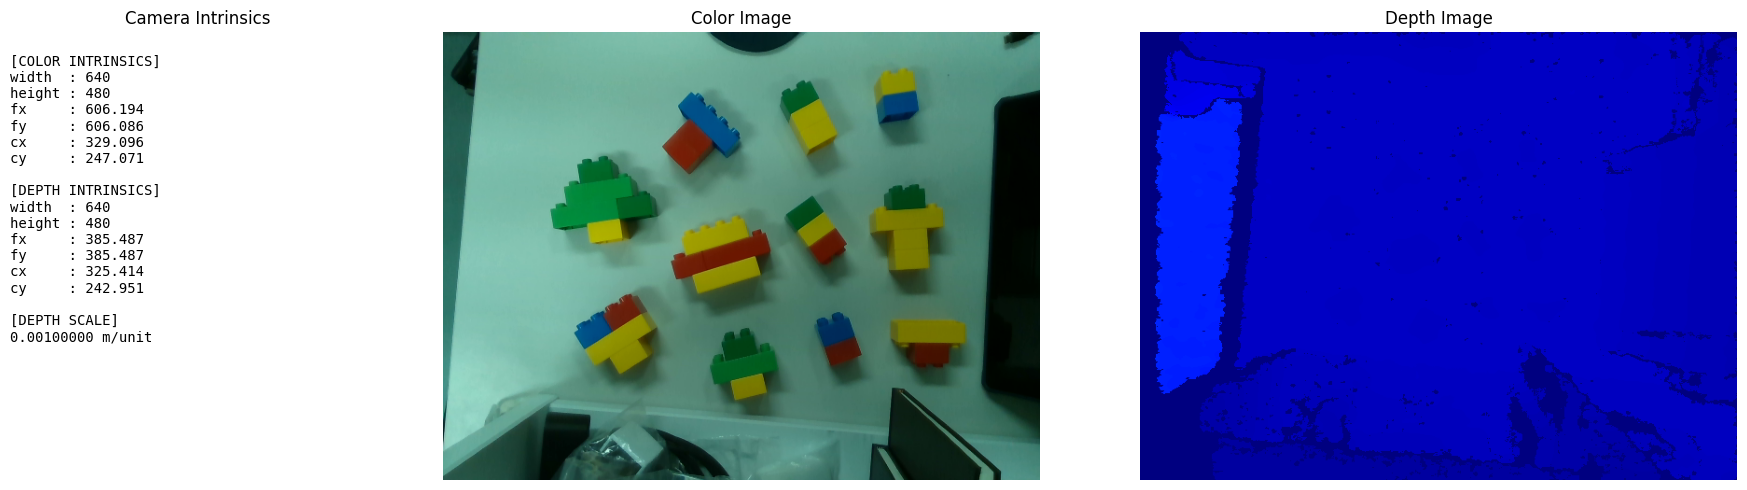

In [7]:
color_img, depth_img, intrinsics = capture_color_depth_and_save_intrinsics(
    devices=devices,
    image_save_path="output/realsense_color.png",
    depth_save_path="output/realsense_depth_raw.png",
    yaml_save_path="output/realsense_intrinsics.yaml",
    width=640,
    height=480,
    fps=30,
    warmup_frames=10,
    show=True
)

## **binaryzation first**

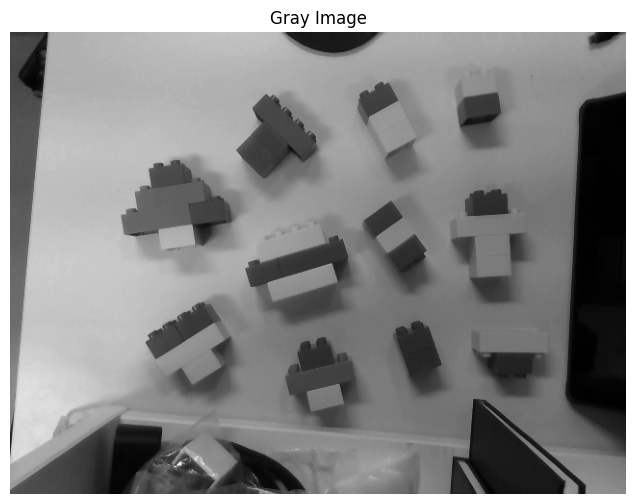

In [8]:
gray = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap="gray")
plt.title("Gray Image")
plt.axis("off")
plt.show()

# 기법: Gaussian Blur

카메라 이미지에는 조명 변화, 센서 노이즈, 표면 반사 등으로 인해 작은 점 잡음이나 불규칙한 픽셀 변화가 포함될 수 있다.  
이러한 노이즈는 이진화, 엣지 검출, contour 추출 과정에서 불필요한 경계로 검출될 수 있다.

$$
I_{blur}(x, y) = G_{\sigma}(x, y) * I(x, y)
$$

Gaussian Blur는 가우시안 커널을 이미지에 컨볼루션하여 주변 픽셀과의 가중 평균을 계산하는 평활화 기법이다.  
중심 픽셀에 가까운 값일수록 큰 가중치를 가지며, 멀어질수록 작은 가중치를 갖는다.  
이를 통해 작은 노이즈를 줄이고 이미지의 급격한 밝기 변화를 완화할 수 있다.  
다만 커널 크기나 $\sigma$ 값이 커지면 객체의 경계도 함께 흐려질 수 있다.  
본 과정에서는 후속 이진화와 경계 검출을 안정화하기 위한 전처리로 사용한다.

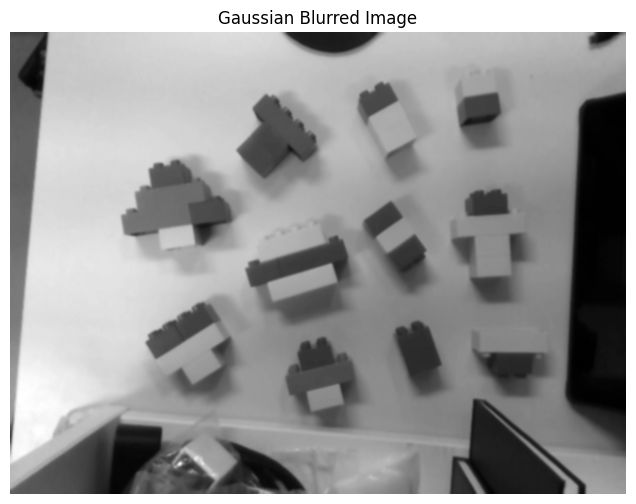

In [9]:
blurred = cv2.GaussianBlur(
    gray,
    ksize=(5, 5),
    sigmaX=0
)

plt.figure(figsize=(8, 6))
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred Image")
plt.axis("off")
plt.show()

# 기법: CLAHE

조명 불균일, 반사, 그림자 등으로 인해 grayscale 이미지의 일부 영역에서 명암 대비가 낮아질 수 있다.  
이 경우 객체의 경계나 표면 특징이 약해져 후속 이진화, 엣지 검출, 마스크 생성이 불안정해질 수 있다.

$$
I_{CLAHE}(x, y) = T_{local}(I(x, y))
$$

CLAHE는 이미지를 작은 타일 영역으로 나누고 각 영역마다 히스토그램 평활화를 수행한다.  
일반 히스토그램 평활화와 달리 국소 영역의 대비를 향상시키는 데 유리하다.  
`clipLimit`은 특정 밝기 구간이 과도하게 증폭되는 것을 제한한다.  
`tileGridSize`는 이미지를 나누는 지역 영역의 크기를 의미한다.  
본 과정에서는 grayscale 이미지에 CLAHE를 적용하여 객체 경계와 표면 명암 차이를 강화한다.

In [10]:
def apply_clahe_to_gray_image(
    gray_img,
    clip_limit=2.0,
    tile_grid_size=(8, 8),
    show=True
):
    """
    Grayscale 이미지에 CLAHE를 적용하는 함수.

    Parameters
    ----------
    gray_img : np.ndarray
        입력 grayscale 이미지
    clip_limit : float
        대비 제한 값
    tile_grid_size : tuple
        CLAHE 타일 크기
    show : bool
        True이면 원본과 결과를 좌우로 출력

    Returns
    -------
    clahe_img : np.ndarray
        CLAHE 적용 결과 이미지
    """

    if gray_img is None:
        raise ValueError("gray_img가 None입니다.")

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    clahe_img = clahe.apply(gray_img)

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(gray_img, cmap="gray")
        axes[0].set_title("Original Gray")
        axes[0].axis("off")

        axes[1].imshow(clahe_img, cmap="gray")
        axes[1].set_title("CLAHE Result")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return clahe_img

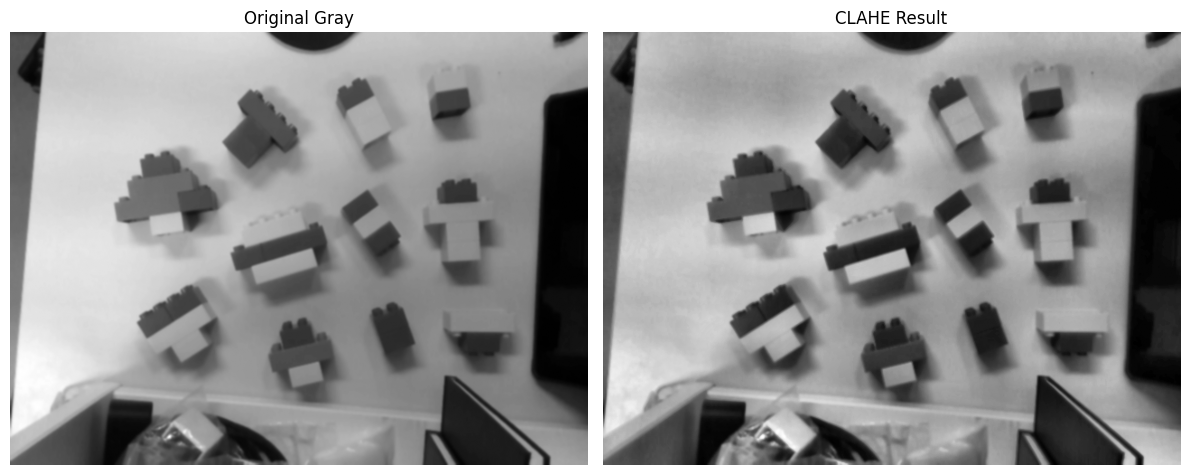

In [11]:
clahe_img = apply_clahe_to_gray_image(
    gray_img=blurred,
    clip_limit=2.0,
    tile_grid_size=(8, 8),
    show=True
)

# 기법: Canny Edge Detection

CLAHE를 통해 국소 대비가 향상된 이미지에서는 객체 경계와 명암 변화가 더 뚜렷하게 나타난다.  
Canny Edge Detection은 이러한 밝기 변화가 큰 지점을 이용해 객체의 경계 후보를 검출하기 위해 사용한다.

$$
G = \sqrt{G_x^2 + G_y^2}
$$

Canny Edge Detection은 이미지의 gradient를 계산하여 밝기 변화가 큰 영역을 찾는다.  
이후 non-maximum suppression을 통해 경계를 얇게 만들고, 이중 임계값을 이용해 강한 경계와 약한 경계를 구분한다.  
`threshold1`은 약한 edge 기준값이고, `threshold2`는 강한 edge 기준값이다.  
두 값이 낮으면 edge가 많이 검출되고, 높으면 강한 경계만 남는다.  
본 과정에서는 CLAHE 결과 이미지에서 객체의 외곽선과 내부 경계 후보를 확인하는 용도로 사용한다.

In [12]:
def apply_canny_edge(
    input_img,
    threshold1=50,
    threshold2=150,
    aperture_size=3,
    L2gradient=True,
    show=True
):
    """
    입력 grayscale 이미지에 Canny Edge Detection을 적용하는 함수.

    Parameters
    ----------
    input_img : np.ndarray
        입력 grayscale 이미지. 예: clahe_img
    threshold1 : int
        낮은 임계값
    threshold2 : int
        높은 임계값
    aperture_size : int
        Sobel 연산 커널 크기. 보통 3 사용.
    L2gradient : bool
        True이면 더 정확한 gradient magnitude 계산 사용.
    show : bool
        True이면 입력 이미지와 Canny 결과를 좌우로 표시.

    Returns
    -------
    canny_edges : np.ndarray
        Canny edge 결과 이미지. uint8, 0 또는 255.
    """

    import cv2
    import matplotlib.pyplot as plt

    if input_img is None:
        raise ValueError("input_img가 None입니다.")

    canny_edges = cv2.Canny(
        input_img,
        threshold1=threshold1,
        threshold2=threshold2,
        apertureSize=aperture_size,
        L2gradient=L2gradient
    )

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(input_img, cmap="gray")
        axes[0].set_title("Input Image")
        axes[0].axis("off")

        axes[1].imshow(canny_edges, cmap="gray")
        axes[1].set_title(f"Canny Edge ({threshold1}, {threshold2})")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return canny_edges

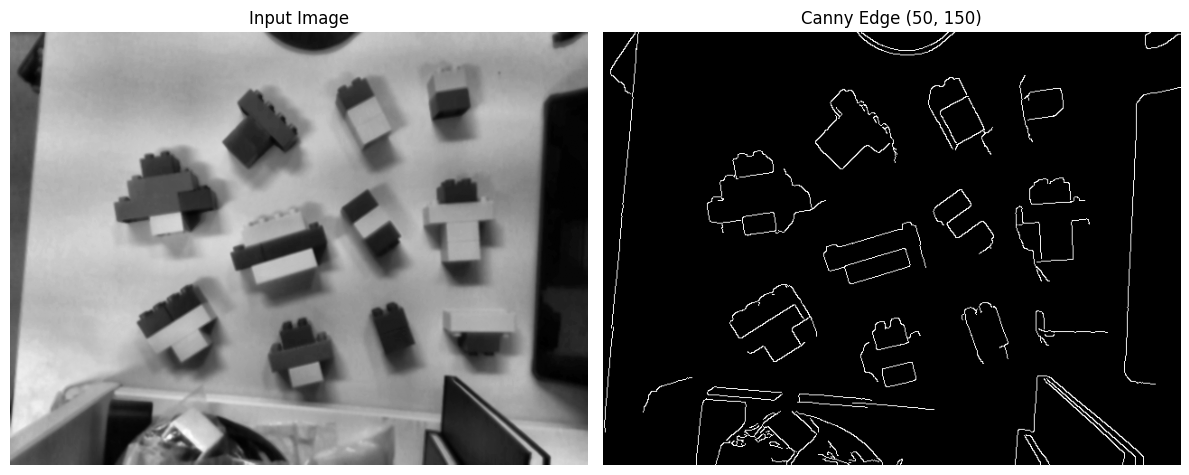

In [13]:
canny_edges = apply_canny_edge(
    input_img=clahe_img,
    threshold1=50,
    threshold2=150,
    aperture_size=3,
    L2gradient=True,
    show=True
)

# 기법: Morphological Operation

Canny Edge 결과는 객체 경계가 끊기거나 작은 잡음 edge가 함께 검출되는 문제가 발생할 수 있다.  
이 경우 후속 contour 검출에서 하나의 객체가 여러 조각으로 분리되거나, 불필요한 작은 영역이 검출될 수 있다.

$$
A \oplus B = \{ z \mid (\hat{B})_z \cap A \neq \emptyset \}
$$

Morphological Operation은 이진 이미지에서 커널을 이용해 흰색 영역의 형태를 보정하는 연산이다.  
Dilation은 흰색 영역을 확장하고, Erosion은 흰색 영역을 축소한다.  
Closing은 Dilation 후 Erosion을 수행하여 끊어진 경계나 작은 구멍을 메우는 데 사용된다.  
Opening은 Erosion 후 Dilation을 수행하여 작은 잡음을 제거하는 데 사용된다.  
본 과정에서는 Canny Edge 결과의 끊어진 경계를 보정하고 contour 검출 안정성을 높이기 위해 사용한다.

In [14]:
def apply_morphology_to_edges(
    edge_img,
    kernel_size=(3, 3),
    close_iterations=1,
    open_iterations=0,
    dilate_iterations=0,
    erode_iterations=0,
    show=True
):
    """
    Canny edge 결과에 모폴로지 연산을 적용하는 함수.

    Parameters
    ----------
    edge_img : np.ndarray
        Canny edge image. uint8, 0 또는 255 이미지.
    kernel_size : tuple
        모폴로지 연산에 사용할 커널 크기.
    close_iterations : int
        Closing 반복 횟수. 끊어진 edge 연결에 사용.
    open_iterations : int
        Opening 반복 횟수. 작은 잡음 제거에 사용.
    dilate_iterations : int
        Dilation 반복 횟수. edge를 두껍게 만듦.
    erode_iterations : int
        Erosion 반복 횟수. edge를 얇게 하거나 작은 영역 제거.
    show : bool
        True이면 결과를 시각화.

    Returns
    -------
    morph_img : np.ndarray
        모폴로지 연산이 적용된 edge 이미지.
    """

    import cv2
    import numpy as np
    import matplotlib.pyplot as plt

    if edge_img is None:
        raise ValueError("edge_img가 None입니다.")

    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        kernel_size
    )

    morph_img = edge_img.copy()

    # 1. Closing: 끊어진 경계 연결
    if close_iterations > 0:
        morph_img = cv2.morphologyEx(
            morph_img,
            cv2.MORPH_CLOSE,
            kernel,
            iterations=close_iterations
        )

    # 2. Opening: 작은 잡음 제거
    if open_iterations > 0:
        morph_img = cv2.morphologyEx(
            morph_img,
            cv2.MORPH_OPEN,
            kernel,
            iterations=open_iterations
        )

    # 3. Dilation: edge 두껍게
    if dilate_iterations > 0:
        morph_img = cv2.dilate(
            morph_img,
            kernel,
            iterations=dilate_iterations
        )

    # 4. Erosion: edge 줄이기
    if erode_iterations > 0:
        morph_img = cv2.erode(
            morph_img,
            kernel,
            iterations=erode_iterations
        )

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(edge_img, cmap="gray")
        axes[0].set_title("Original Edge")
        axes[0].axis("off")

        axes[1].imshow(morph_img, cmap="gray")
        axes[1].set_title(
            f"Morphology Result\n"
            f"kernel={kernel_size}, close={close_iterations}, open={open_iterations}"
        )
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return morph_img

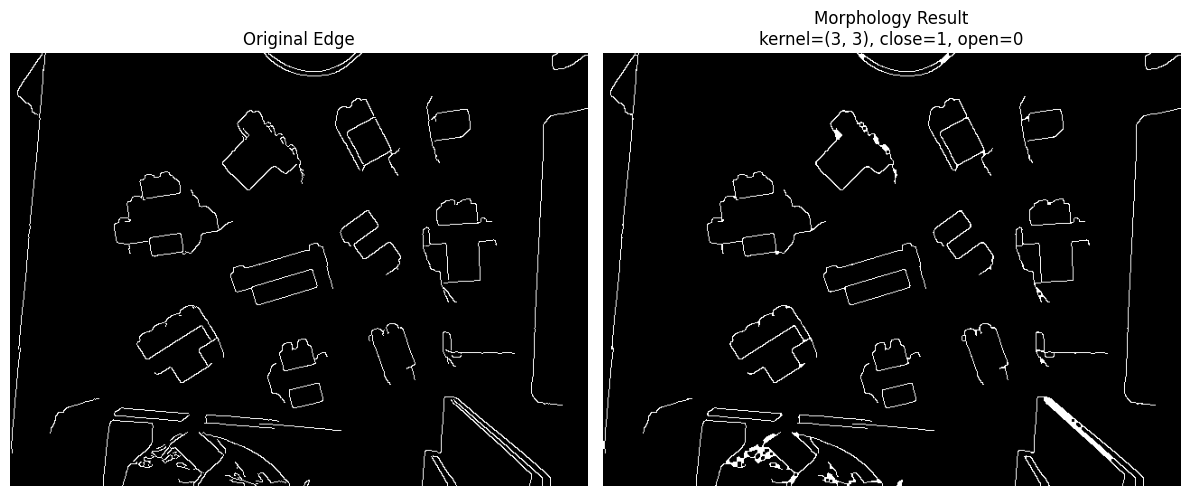

In [21]:
morph_edges = apply_morphology_to_edges(
    edge_img=canny_edges,
    kernel_size=(3, 3),
    close_iterations=1,
    open_iterations=0,
    show=True
)

# 기법: Contour Detection

Canny와 Morphology 결과는 객체 경계 후보를 이진 이미지 형태로 표현한다.  
Contour Detection은 이 경계 픽셀들을 연결된 외곽선 단위로 묶어 객체 후보 영역을 추출하기 위해 사용한다.

$$
C_i = \{(x, y) \mid (x, y) \in \text{connected boundary pixels}\}
$$

Contour는 이진 이미지에서 연결된 흰색 픽셀들의 외곽 경계를 의미한다.  
검출된 contour는 면적, 둘레, bounding box, 중심점 등의 기하 정보를 계산하는 데 사용할 수 있다.  
작은 contour는 노이즈일 가능성이 높으므로 `min_area`로 필터링한다.  
큰 배경 경계나 화면 테두리는 `max_area` 조건으로 제거할 수 있다.  
본 과정에서는 객체 후보의 위치와 영역을 확인하기 위한 중간 단계로 contour를 사용한다.

In [22]:
def find_and_draw_contours(
    binary_img,
    color_img,
    min_area=100,
    max_area=None,
    retrieval_mode=cv2.RETR_EXTERNAL,
    approximation=cv2.CHAIN_APPROX_SIMPLE,
    show=True
):
    """
    이진 이미지에서 contour를 검출하고,
    원본 color 이미지 위에 contour와 bounding box를 표시한다.

    Parameters
    ----------
    binary_img : np.ndarray
        Canny 또는 Morphology 결과 이미지. uint8, 0/255 이진 이미지.
    color_img : np.ndarray
        원본 OpenCV BGR 컬러 이미지.
    min_area : float
        이 값보다 작은 contour는 노이즈로 보고 제거.
    max_area : float or None
        이 값보다 큰 contour는 제거. None이면 사용하지 않음.
    retrieval_mode : int
        contour 검색 방식. 기본값은 cv2.RETR_EXTERNAL.
    approximation : int
        contour 근사 방식.
    show : bool
        True이면 결과를 시각화.

    Returns
    -------
    filtered_contours : list
        필터링된 contour 리스트.

    contour_info_list : list of dict
        contour별 면적, 둘레, bounding box, 중심점 정보.

    vis_img_bgr : np.ndarray
        contour가 그려진 BGR 이미지.
    """

    import cv2
    import numpy as np
    import matplotlib.pyplot as plt

    if binary_img is None:
        raise ValueError("binary_img가 None입니다.")

    if color_img is None:
        raise ValueError("color_img가 None입니다.")

    # findContours는 입력 이미지를 변경할 수 있으므로 copy 사용
    contours, hierarchy = cv2.findContours(
        binary_img.copy(),
        retrieval_mode,
        approximation
    )

    print(f"[INFO] raw contours count: {len(contours)}")

    filtered_contours = []
    contour_info_list = []

    vis_img_bgr = color_img.copy()

    for idx, cnt in enumerate(contours):
        area = cv2.contourArea(cnt)

        if area < min_area:
            continue

        if max_area is not None and area > max_area:
            continue

        perimeter = cv2.arcLength(cnt, True)
        x, y, w, h = cv2.boundingRect(cnt)

        # 중심점 계산
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
        else:
            cx = x + w // 2
            cy = y + h // 2

        filtered_contours.append(cnt)

        contour_info = {
            "index": idx,
            "area": float(area),
            "perimeter": float(perimeter),
            "bbox": {
                "x": int(x),
                "y": int(y),
                "w": int(w),
                "h": int(h)
            },
            "center": {
                "cx": int(cx),
                "cy": int(cy)
            }
        }

        contour_info_list.append(contour_info)

        # contour 표시
        cv2.drawContours(vis_img_bgr, [cnt], -1, (0, 255, 0), 2)

        # bounding box 표시
        cv2.rectangle(vis_img_bgr, (x, y), (x + w, y + h), (255, 0, 0), 2)

        # 중심점 표시
        cv2.circle(vis_img_bgr, (cx, cy), 4, (0, 0, 255), -1)

        # 번호 표시
        cv2.putText(
            vis_img_bgr,
            str(len(filtered_contours) - 1),
            (x, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 255),
            1,
            cv2.LINE_AA
        )

    print(f"[INFO] filtered contours count: {len(filtered_contours)}")

    if show:
        vis_img_rgb = cv2.cvtColor(vis_img_bgr, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        axes[0].imshow(binary_img, cmap="gray")
        axes[0].set_title("Input Binary Image")
        axes[0].axis("off")

        axes[1].imshow(vis_img_rgb)
        axes[1].set_title("Detected Contours")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return filtered_contours, contour_info_list, vis_img_bgr

[INFO] raw contours count: 28
[INFO] filtered contours count: 16


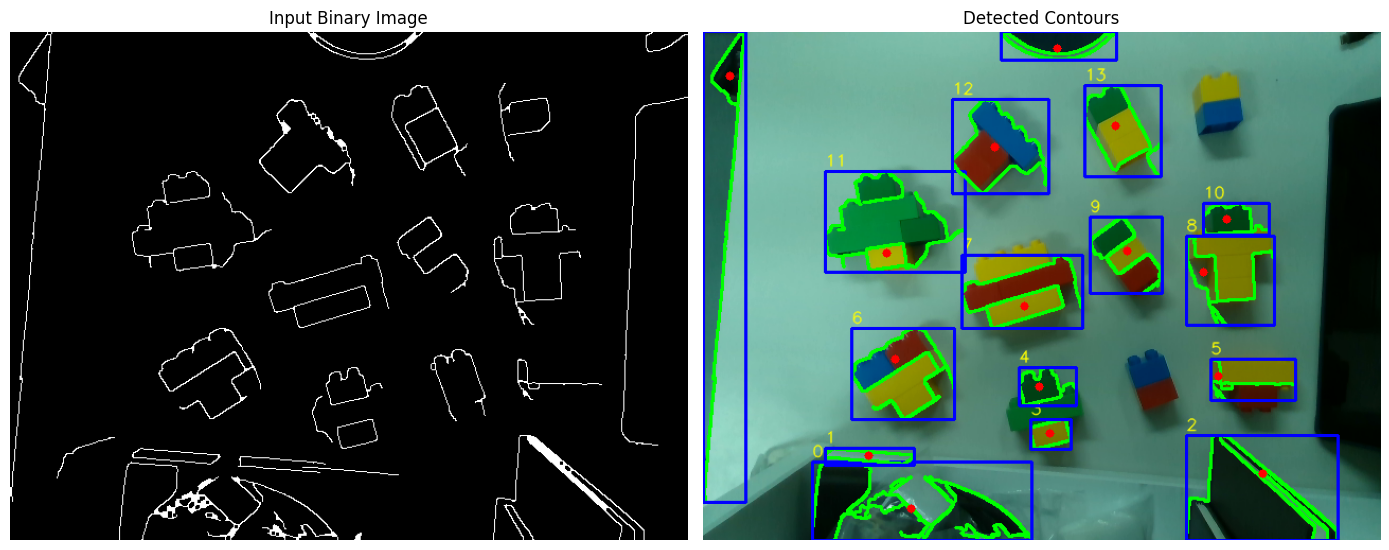

In [25]:
contours, contour_infos, contour_vis_img = find_and_draw_contours(
    binary_img=morph_edges,
    color_img=color_img,
    min_area=100,
    max_area=None,
    retrieval_mode=cv2.RETR_EXTERNAL,
    approximation=cv2.CHAIN_APPROX_SIMPLE,
    show=True
)

# 기법: Non-Maximum Suppression

Contour 검출 결과에서는 하나의 객체 주변에 여러 개의 bounding box가 중복 생성될 수 있다.  
이 경우 동일 객체가 여러 후보로 처리되어 후속 위치 추정이나 객체 개수 계산이 불안정해질 수 있다.

$$
IoU(A, B) = \frac{Area(A \cap B)}{Area(A \cup B)}
$$

Non-Maximum Suppression은 bounding box 간의 겹침 정도인 IoU를 계산하여 중복 후보를 제거하는 방법이다.  
각 box는 score를 가지며, 일반적으로 score가 높은 box를 먼저 선택한다.  
선택된 box와 IoU가 일정 기준 이상으로 겹치는 다른 box들은 제거된다.  
본 과정에서는 contour confidence가 없으므로 contour area를 score로 사용한다.  
이를 통해 중복된 contour bounding box를 줄이고 객체 후보를 정리한다.

In [26]:
def compute_iou_xywh(box_a, box_b):
    """
    xywh 형식 box 2개의 IoU 계산.

    box format:
    [x, y, w, h]
    """

    x1_a, y1_a, w_a, h_a = box_a
    x2_a = x1_a + w_a
    y2_a = y1_a + h_a

    x1_b, y1_b, w_b, h_b = box_b
    x2_b = x1_b + w_b
    y2_b = y1_b + h_b

    inter_x1 = max(x1_a, x1_b)
    inter_y1 = max(y1_a, y1_b)
    inter_x2 = min(x2_a, x2_b)
    inter_y2 = min(y2_a, y2_b)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = w_a * h_a
    area_b = w_b * h_b

    union_area = area_a + area_b - inter_area

    if union_area <= 0:
        return 0.0

    return inter_area / union_area


def nms_contours_by_bbox(
    contours,
    contour_infos,
    iou_threshold=0.3,
    score_key="area"
):
    """
    contour bounding box에 대해 NMS를 적용한다.

    Parameters
    ----------
    contours : list
        find_and_draw_contours()에서 반환된 contour 리스트
    contour_infos : list of dict
        contour 정보 리스트
    iou_threshold : float
        이 값보다 IoU가 크면 중복 box로 보고 제거
    score_key : str
        score로 사용할 contour_infos의 key. 기본값은 area.

    Returns
    -------
    kept_contours : list
        NMS 후 남은 contour 리스트

    kept_infos : list of dict
        NMS 후 남은 contour 정보 리스트

    kept_indices : list
        원래 contour_infos 기준으로 살아남은 index
    """

    if len(contours) != len(contour_infos):
        raise ValueError("contours와 contour_infos의 길이가 다릅니다.")

    if len(contours) == 0:
        return [], [], []

    boxes = []
    scores = []

    for info in contour_infos:
        bbox = info["bbox"]
        boxes.append([
            bbox["x"],
            bbox["y"],
            bbox["w"],
            bbox["h"]
        ])

        scores.append(float(info[score_key]))

    # score 높은 순서대로 정렬
    indices = list(range(len(boxes)))
    indices.sort(key=lambda i: scores[i], reverse=True)

    kept_indices = []

    while len(indices) > 0:
        current = indices.pop(0)
        kept_indices.append(current)

        remaining = []

        for idx in indices:
            iou = compute_iou_xywh(boxes[current], boxes[idx])

            if iou < iou_threshold:
                remaining.append(idx)

        indices = remaining

    kept_contours = [contours[i] for i in kept_indices]
    kept_infos = [contour_infos[i] for i in kept_indices]

    print(f"[INFO] before NMS: {len(contours)}")
    print(f"[INFO] after  NMS: {len(kept_contours)}")
    print(f"[INFO] IoU threshold: {iou_threshold}")

    return kept_contours, kept_infos, kept_indices

In [27]:
def draw_nms_contours(
    color_img,
    kept_contours,
    kept_infos,
    show=True
):
    """
    NMS 후 남은 contour와 bounding box를 원본 이미지에 표시한다.
    """

    import cv2
    import matplotlib.pyplot as plt

    if color_img is None:
        raise ValueError("color_img가 None입니다.")

    vis_img_bgr = color_img.copy()

    for i, (cnt, info) in enumerate(zip(kept_contours, kept_infos)):
        bbox = info["bbox"]
        center = info["center"]

        x = bbox["x"]
        y = bbox["y"]
        w = bbox["w"]
        h = bbox["h"]

        cx = center["cx"]
        cy = center["cy"]

        # contour
        cv2.drawContours(vis_img_bgr, [cnt], -1, (0, 255, 0), 2)

        # bounding box
        cv2.rectangle(
            vis_img_bgr,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

        # center
        cv2.circle(
            vis_img_bgr,
            (cx, cy),
            4,
            (0, 0, 255),
            -1
        )

        # index + area
        cv2.putText(
            vis_img_bgr,
            f"{i} A:{info['area']:.0f}",
            (x, max(0, y - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (0, 255, 255),
            1,
            cv2.LINE_AA
        )

    if show:
        vis_img_rgb = cv2.cvtColor(vis_img_bgr, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 7))
        plt.imshow(vis_img_rgb)
        plt.title("NMS Contours")
        plt.axis("off")
        plt.show()

    return vis_img_bgr

[INFO] before NMS: 16
[INFO] after  NMS: 16
[INFO] IoU threshold: 0.3


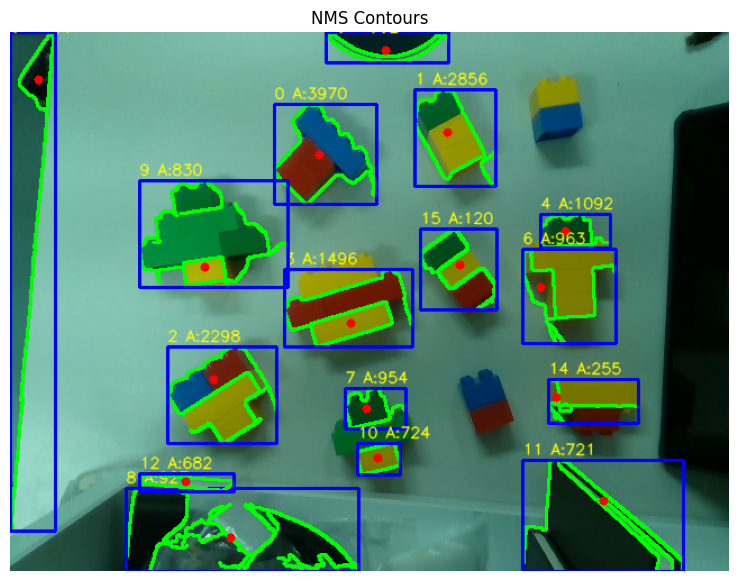

In [28]:
nms_contours, nms_infos, nms_indices = nms_contours_by_bbox(
    contours=contours,
    contour_infos=contour_infos,
    iou_threshold=0.3,
    score_key="area"
)

nms_vis_img = draw_nms_contours(
    color_img=color_img,
    kept_contours=nms_contours,
    kept_infos=nms_infos,
    show=True
)